In [1]:
import pandas as pd
import seaborn as sns
insurance_data=pd.read_csv("insurance_csv.csv")
insurance_data

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


<Axes: xlabel='bmi', ylabel='charges'>

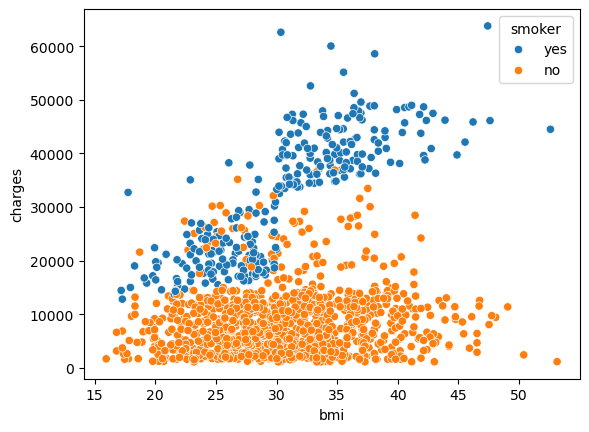

In [2]:
sns.scatterplot(
    x=insurance_data["bmi"],
    y=insurance_data["charges"],
    hue=insurance_data["smoker"])

In [3]:
import pandas as pd
x=insurance_data.drop(columns=["charges"])
y=insurance_data["charges"]
x=pd.get_dummies(x,columns=["region"],drop_first=True,dtype=int)

In [4]:
x["sex"]=x["sex"].map({"female":1,"male":0})
x["smoker"]=x["smoker"].map({"yes":1,"no":0})
x["age_smoker"]=x["age"]*x["smoker"]
x["bmi_smoker"]=x["bmi"]*x["smoker"]
x.head()

,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest,age_smoker,bmi_smoker
0,19,1,27.900,0,1,0,0,1,19,27.9
1,18,0,33.770,1,0,0,1,0,0,0.0
2,28,0,33.000,3,0,0,1,0,0,0.0
3,33,0,22.705,0,0,1,0,0,0,0.0
4,32,0,28.880,0,0,1,0,0,0,0.0


In [5]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
x_test.head()

,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest,age_smoker,bmi_smoker
764,45,1,25.175,2,0,0,0,0,0,0.000
887,36,1,30.020,0,0,1,0,0,0,0.000
890,64,1,26.885,0,1,1,0,0,64,26.885
1293,46,0,25.745,3,0,1,0,0,0,0.000
259,19,0,31.920,0,1,1,0,0,19,31.920


In [6]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train,y_train)
y_train_pred=model.predict(x_test)
r2_train=r2_score(y_test,y_train_pred)
print(r2_train)
print(r2)


NameError: name 'r2_score' is not defined

In [ ]:
y_test

In [ ]:
from sklearn.metrics import r2_score
r2=r2_score(y_test,y_pred)
r2

In [ ]:
n=x_test.shape[0]
p=x_test.shape[1]
adjusted_r2=1-((1-r2)*(n-1)/(n-p-1))
adjusted_r2

In [ ]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error
import pandas as pd
from sklearn.model_selection import train_test_split

In [ ]:
insurance_data=pd.read_csv("insurance_csv.csv")

In [ ]:
x=insurance_data.drop(columns=["charges"])
y=insurance_data["charges"]
x=pd.get_dummies(x,columns=["region"],drop_first=True,dtype=int)

In [ ]:
x["sex"]=x["sex"].map({"female":1,"male":0})
x["smoker"]=x["smoker"].map({"yes":1,"no":0})
x["age_smoker"]=x["age"]*x["smoker"]
x["bmi_smoker"]=x["bmi"]*x["smoker"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


In [ ]:
from sklearn.metrics import mean_squared_error
import seaborn as sns
from sklearn.linear_model import Lasso
alphas=[0.001,0.1,1,2,5,10,20,30,40,50,100]
mses=[]
for a in alphas:
    lasso_model=Lasso(alpha=a)
    lasso_model.fit(x_train,y_train)
    y_pred=lasso_model.predict(x_test)
    mse=mean_squared_error(y_test,y_pred)
    print(mse)
    mses.append(mse)
sns.lineplot(x=alphas,y=mses,marker="o")

In [ ]:
from sklearn.linear_model import LassoCV
from sklearn.metrics import mean_squared_error,r2_score
a=[0.0001,0.1,1,2,5,10,20,30,40,50,100]
lasso_cv_model=LassoCV(
    alphas=a,
    cv=5,
    max_iter=1000,
    random_state=42)
lasso_cv_model.fit(x_train,y_train)
print(lasso_cv_model.alpha_)
y_pred=lasso_cv_model.predict(x_test)
mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
print(mse)
print(r2)


In [ ]:
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score

In [ ]:
df=pd.read_csv("heart.csv")
df.columns

In [ ]:
x=df.drop("target",axis=1)
y=df["target"]
y.head()

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
x_train[x_train==1]

In [ ]:

model=LogisticRegression(max_iter=2000)
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
print("accuracy score:",accuracy_score(y_test,y_pred)*100,"%")
print("precision:",precision_score(y_test,y_pred)*100,"%")

In [ ]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred)
print(cm)

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

In [ ]:
import pandas as pd
from sklearn.metrics import precision_score,accuracy_score,recall_score
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB


In [ ]:
df=pd.read_csv("heart.csv")

In [ ]:
df.head()

In [ ]:
x=df.drop("target",axis=1)
y=df["target"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


In [ ]:
gnb_model=GaussianNB()
gnb_model.fit(x_train,y_train)
y_pred=gnb_model.predict(x_test)

In [ ]:
print("recall score:",recall_score(y_test,y_pred))
print("accuracy score:",accuracy_score(y_test,y_pred))
print("precision score:",precision_score(y_test,y_pred))

In [ ]:
import pandas as pd
from sklearn.metrics import precision_score,accuracy_score,recall_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier


In [ ]:
df=pd.read_csv("heart.csv")
df


In [ ]:
x=df.drop("target",axis=1)
y=df["target"]


In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)


In [ ]:
from sklearn.model_selection import GridSearchCV
classifier=KNeighborsClassifier()
param_grid={"n_neighbors":[3,5,7,9]}
classifierCV=GridSearchCV(
    classifier,
    param_grid,
    cv=5)
classifierCV.fit(x_train_scaled,y_train)
y_pred=classifierCV.predict(x_test_scaled)


In [ ]:
print("recall score:",recall_score(y_test,y_pred))
print("accuracy score:",accuracy_score(y_test,y_pred))
print("precision score:",precision_score(y_test,y_pred))
results=pd.DataFrame(classifierCV.cv_results_)
print(results[["param_n_neighbors","mean_test_score"]])
print(classifierCV.best_params_)

In [ ]:
from sklearn.pipeline import Pipeline
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
pipe=Pipeline([("scaler",StandardScaler()),
                   ("knn",KNeighborsClassifier())])
param_grid={"knn__n_neighbors":[3,5,7,9]}
classifierCV=GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring="recall")
classifierCV.fit(x_train,y_train)
y_pred=classifierCV.predict(x_test)
print("recall score:",recall_score(y_test,y_pred))
print("accuracy score:",accuracy_score(y_test,y_pred))
print("precision score:",precision_score(y_test,y_pred))
print(classifierCV.best_params_)



In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [ ]:
df=pd.read_csv("loan_approval_data.csv")
df.head()

In [ ]:
categorical_cols=df.select_dtypes(include=["object"]).columns
numerical_cols=df.select_dtypes(include=["number"]).columns

In [ ]:
from sklearn.impute import SimpleImputer
num_imp=SimpleImputer(strategy="mean")
df[numerical_cols]=num_imp.fit_transform(df[numerical_cols])
cat_imp=SimpleImputer(strategy="most_frequent")
df[categorical_cols]=cat_imp.fit_transform(df[categorical_cols])

In [ ]:
df.head()


In [ ]:
gender_cnt=df["Gender"].value_counts()
ax=sns.barplot(gender_cnt)
ax.bar_label(ax.containers[0])


In [ ]:
edu_dnt=df["Education_Level"].value_counts()
ax=sns.barplot(edu_dnt)


In [ ]:
sns.histplot(
    data=df,
    x="Applicant_Income",
    bins=20)

In [ ]:
sns.histplot(
    data=df,
    x="Coapplicant_Income",
    bins=5)

In [ ]:
sns.boxplot(
    data=df,
    x="Loan_Approved",
    y="Applicant_Income")

In [ ]:
fig,axes=plt.subplots(2,2)
sns.boxplot(ax=axes[0,0],data=df,x="Loan_Approved",y="Applicant_Income")
sns.boxplot(ax=axes[0,1],data=df,x="Loan_Approved",y="Credit_Score")
sns.boxplot(ax=axes[1,0],data=df,x="Loan_Approved",y="DTI_Ratio")
sns.boxplot(ax=axes[1,1],data=df,x="Loan_Approved",y="Savings")
plt.tight_layout()

In [ ]:
sns.histplot(
    data=df,
    x="Credit_Score",
    hue="Loan_Approved",
    bins=20,
    multiple="dodge"
)

In [ ]:
df=df.drop("Applicant_ID",axis=1)
df.head()


In [ ]:
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
le=LabelEncoder()
df["Education_Level"]=le.fit_transform(df["Education_Level"])
df["Loan_Approved"]=le.fit_transform(df["Loan_Approved"])
df.head()
df.columns

In [ ]:
cols=["Employment_Status","Marital_Status","Loan_Purpose","Property_Area","Gender","Employer_Category"]
one=OneHotEncoder(drop="first",sparse_output=False,handle_unknown="ignore")
encoded=one.fit_transform(df[cols])
encoded_df=pd.DataFrame(encoded,columns=one.get_feature_names_out(cols),index=df.index)

In [ ]:
df=pd.concat([df.drop(columns=cols),encoded_df],axis=1)
df.head()

In [ ]:
df.head()

In [ ]:
num_cols=df.select_dtypes(include="number")
corr_matrix=num_cols.corr()
plt.figure(figsize=(15,8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".1f",
    cmap="coolwarm")



In [ ]:
num_cols.corr()["Loan_Approved"]


In [ ]:
x=df.drop("Loan_Approved",axis=1)
y=df["Loan_Approved"]


In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
x_test.head()


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score,recall_score,f1_score
log_model=LogisticRegression()
log_model.fit(x_train_scaled,y_train)
y_pred=log_model.predict(x_test_scaled)
print("recall score:",recall_score(y_test,y_pred))
print("accuracy score:",accuracy_score(y_test,y_pred))
print("precision score:",precision_score(y_test,y_pred))
print("cm:",confusion_matrix(y_test,y_pred))

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier(n_neighbors=19)
knn.fit(x_train_scaled,y_train)
y_pred=knn.predict(x_test_scaled)
print("recall score:",recall_score(y_test,y_pred))
print("accuracy score:",accuracy_score(y_test,y_pred))
print("precision score:",precision_score(y_test,y_pred))
print("cm:",confusion_matrix(y_test,y_pred))

In [ ]:
from sklearn.naive_bayes import GaussianNB
nb_model=GaussianNB()
nb_model.fit(x_train_scaled,y_train)
y_pred=nb_model.predict(x_test_scaled)
print("recall score:",recall_score(y_test,y_pred))
print("accuracy score:",accuracy_score(y_test,y_pred))
print("precision score:",precision_score(y_test,y_pred))
print("cm:",confusion_matrix(y_test,y_pred))


In [ ]:
df["DTI_Ratio_sq"]=df["DTI_Ratio"]**2
df["Credit_Score_sq"]=df["Credit_Score"]**2

In [ ]:
x=df.drop(columns=["Loan_Approved","Credit_Score","DTI_Ratio"])
y=df["Loan_Approved"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)



In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score,recall_score,f1_score
log_model=LogisticRegression()
log_model.fit(x_train_scaled,y_train)
y_pred=log_model.predict(x_test_scaled)
print("recall score:",recall_score(y_test,y_pred))
print("accuracy score:",accuracy_score(y_test,y_pred))
print("precision score:",precision_score(y_test,y_pred))
print("cm:",confusion_matrix(y_test,y_pred))

In [ ]:


from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier(n_neighbors=19)
knn.fit(x_train_scaled,y_train)
y_pred=knn.predict(x_test_scaled)
print("recall score:",recall_score(y_test,y_pred))
print("accuracy score:",accuracy_score(y_test,y_pred))
print("precision score:",precision_score(y_test,y_pred))
print("cm:",confusion_matrix(y_test,y_pred))


In [ ]:
from sklearn.naive_bayes import GaussianNB
nb_model=GaussianNB()
nb_model.fit(x_train_scaled,y_train)
y_pred=nb_model.predict(x_test_scaled)
print("recall score:",recall_score(y_test,y_pred))
print("accuracy score:",accuracy_score(y_test,y_pred))
print("precision score:",precision_score(y_test,y_pred))
print("cm:",confusion_matrix(y_test,y_pred))


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

In [ ]:
tit=sns.load_dataset("titanic")

In [ ]:
tit.head()
features=["pclass","sex","fare","embarked","age"]
target=["survived"]

In [ ]:
tit.isnull().sum()

In [ ]:
from sklearn.impute import SimpleImputer
imp_median=SimpleImputer(strategy="median")
tit["age"]=imp_median.fit_transform(tit[["age"]])
imp_freq=SimpleImputer(strategy="most_frequent")
tit["embarked"]=imp_freq.fit_transform(tit[["embarked"]]).ravel()

In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
tit["sex"]=le.fit_transform(tit["sex"])
tit["embarked"]=le.fit_transform(tit["embarked"])

In [ ]:
x=tit[features]
y=tit[target]

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


In [ ]:
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier()
model.fit(x_train,y_train)
from sklearn.metrics import accuracy_score
y_pred=model.predict(x_test)
print("accuracy score:",(y_test,y_pred))

In [ ]:
from  sklearn.tree import plot_tree
plt.figure(figsize =(18,10)),
plot_tree(model,
          feature_names=x.columns,
          class_names=["died","survived"],
          filled=True,
          max_depth=4)
plt.tight_layout()
plt.show()
          

In [ ]:
max_depths=[2,3,4,5,6,7,8,9,10]
for depth in max_depths:
    model=DecisionTreeClassifier(max_depth=depth)
    model.fit(x_train,y_train)
    acc=model.score(x_test,y_test)
    print(f" for depth={depth},accuracy={acc}")
    if depth==4:
       plt.figure(figsize=(18,10)),
       plot_tree(model,
              feature_names=x.columns,
              class_names=["died","survived"],
      filled=True)
plt.tight_layout()
plt.show()


In [ ]:
min_samples_split=[5,10,15,20,25,30]
for split in min_samples_split:
    model=DecisionTreeClassifier(max_depth=4,
                                 min_samples_split=split)
    model.fit(x_train,y_train)
    acc=model.score(x_test,y_test)
    print(f"for sample split={split},accuracy={acc}")
    if split==10:
        plt.figure(figsize=(18,10))
        plot_tree(model,
        feature_names=x.columns,
        class_names=["died","survived"],
        filled=True)
        plt.tight_layout()
        plt.show()

In [ ]:
full_tree=DecisionTreeClassifier(random_state=42)

In [ ]:
full_tree.fit(x_train,y_train)
path=full_tree.cost_complexity_pruning_path(x_train,y_train)
ccp_alphas=path.ccp_alphas
print(ccp_alphas)

In [ ]:
trees=[]
for alpha in ccp_alphas:
    model=DecisionTreeClassifier(random_state=42,ccp_alpha=alpha)
    model.fit(x_train,y_train)
    trees.append((model,alpha))
    best_acc=0
    best_alpha=0
    for model,alpha in trees:
        curr_acc=model.score(x_test,y_test)
        if curr_acc>best_acc:
            best_acc=curr_acc
            best_alpha=alpha
    

In [ ]:
best_acc

In [ ]:
best_model=DecisionTreeClassifier(ccp_alpha=best_alpha,max_depth=4)
best_model.fit(x_train,y_train)
plt.figure(figsize=(18,10))
plot_tree(
    best_model,
    feature_names=x.columns,
    class_names=["died","survived"],
    filled=True)
plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
df=load_diabetes(as_frame=True).frame
x=df.drop("target",axis=1)
y=df["target"]


In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)
from sklearn.tree import DecisionTreeRegressor
model=DecisionTreeRegressor(max_depth=7,min_samples_leaf=20)
model.fit(x_train,y_train)
from sklearn.metrics import r2_score,mean_squared_error
y_pred_train=model.predict(x_train)
y_pred_test=model.predict(x_test)
print("MSE train:",(y_train,y_pred_train))
print("MSE test:",(y_test,y_pred_test))

In [ ]:
print("r2 train:",r2_score(y_train,y_pred_train))
print("r2 test:",r2_score(y_test,y_pred_test))

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn import datasets

In [ ]:
df=datasets.load_iris(as_frame=True).frame

In [ ]:
df.isnull().sum()

In [ ]:
df.shape

In [ ]:
df.head()


In [ ]:
x=df.drop("target",axis=1)
y=df["target"]

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [ ]:
svc=SVC()
svc.fit(x_train_scaled,y_train)
y_pred=svc.predict(x_test_scaled)


In [ ]:
from sklearn.metrics import accuracy_score,classification_report
print("accuracy:",accuracy_score(y_test,y_pred))
print("classification report:",classification_report(y_test,y_pred))

In [ ]:
svc=SVC(kernel="linear")
svc.fit(x_train_scaled,y_train)
y_pred=svc.predict(x_test_scaled)
print("accuracy:",accuracy_score(y_test,y_pred))

In [ ]:
svc=SVC(kernel="poly")
svc.fit(x_train_scaled,y_train)
y_pred=svc.predict(x_test_scaled)
print("accuracy score:",accuracy_score(y_test,y_pred))

In [ ]:
svc=SVC(kernel="sigmoid")
svc.fit(x_train_scaled,y_train)
y_pred=svc.predict(x_test_scaled)
print("accuracy score:",accuracy_score(y_test,y_pred))


In [ ]:
c_vals=[0.5,1,2,3,4,5]
for c_val in c_vals:
    svc=SVC(C=c_val,kernel="rbf")
    svc.fit(x_train_scaled,y_train)
    y_pred=svc.predict(x_test_scaled)
    print("c= ",c_val,"& accuracy_score:",accuracy_score(y_test,y_pred))

In [ ]:
from sklearn.svm import SVR
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from sklearn import datasets

In [ ]:
df=datasets.load_diabetes(as_frame=True).frame
df.head()

In [ ]:
x=df.drop("target",axis=1)
y=df["target"]

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
y_scaler=StandardScaler()
y_train_scaled=y_scaler.fit_transform(y_train.values.reshape(-1,1)).ravel()
y_test_scaled=y_scaler.transform(y_test.values.reshape(-1,1)).ravel()

In [ ]:
model=SVR()
model.fit(x_train,y_train_scaled)
y_test_pred=model.predict(x_test)
y_train_pred=model.predict(x_train)

In [ ]:
print("train r2:",r2_score(y_train_scaled,y_train_pred))
print("test r2:",r2_score(y_test_scaled,y_test_pred))


In [ ]:
model=SVR(kernel="")
model.fit(x_train,y_train_scaled)
y_test_pred=model.predict(x_test)
y_train_pred=model.predict(x_train)
print("train r2:",r2_score(y_train_scaled,y_train_pred))
print("test r2:",r2_score(y_test_scaled,y_test_pred))


In [ ]:
from sklearn.model_selection import GridSearchCV
param_grid={
    "C":[1,2,5,10,50,100],
    "kernel":["rbf","linear"],
    "epsilon":[0.01,0.1,0.2,0.3,0.5]}
svr=SVR()
grid_search=GridSearchCV(svr,param_grid,scoring="r2",cv=5)
grid_search.fit(x_train,y_train_scaled)
print("best params_",grid_search.best_params_)


In [ ]:
best_model=SVR(kernel="linear",C=10,epsilon=0.1)
best_model.fit(x_train,y_train_scaled)
y_pred_test=best_model.predict(x_test)
y_pred_train=best_model.predict(x_train)
print("train r2:",r2_score(y_train_scaled,y_pred_train))
print("test r2:",r2_score(y_test_scaled,y_pred_test))

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [ ]:
titanic=sns.load_dataset("titanic")
features=["pclass","sex","fare","embarked","age"]
target=["survived"]

In [ ]:
imp_median=SimpleImputer(strategy="median")
titanic[["age"]]=imp_median.fit_transform(titanic[["age"]])
imp_freq=SimpleImputer(strategy="most_frequent")
titanic[["embarked"]]=imp_freq.fit_transform(titanic[["embarked"]])

In [ ]:
le=LabelEncoder()
titanic["sex"]=le.fit_transform(titanic["sex"])
titanic["embarked"]=le.fit_transform(titanic["embarked"])

In [ ]:
x=titanic[features]
y=titanic["survived"]

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


In [ ]:
model=DecisionTreeClassifier(max_depth=4)
model.fit(x_train,y_train)
y_pred_test=model.predict(x_test)
y_pred_train=model.predict(x_train)
print("training accuracy:",accuracy_score(y_train,y_pred_train)*100,"%")
print("testing accuracy:",accuracy_score(y_test,y_pred_test)*100,"%")

In [ ]:
from sklearn.tree import plot_tree
plt.figure(figsize=(18,10))
plot_tree(model,
          feature_names=x.columns,
          class_names=["died","survived"],
          filled=True)
plt.tight_layout()

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(
    n_estimators=501,
    oob_score=True,
    max_depth=4)
rf.fit(x_train,y_train)
y_pred=rf.predict(x_test)
print("oob score:",rf.oob_score_*100,"%")
print("testing accuracy:",accuracy_score(y_test,y_pred))


In [ ]:
from sklearn.ensemble import BaggingClassifier
from sklearn.linear_model import LogisticRegression
base_model=LogisticRegression(max_iter=1000)
bagging=BaggingClassifier(base_model,
                          n_estimators=201)
bagging.fit(x_train,y_train)
y_pred=bagging.predict(x_test)
print("accuracy socre:",accuracy_score(y_test,y_pred))

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.datasets import make_regression
from sklearn.datasets import make_classification
from sklearn.metrics import accuracy_score

In [ ]:
x,y=make_classification(
    n_samples=500,
    n_features=20,
    n_informative=10,
    random_state=42)

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
gbr=GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42)
gbr.fit(x_train,y_train)
y_pred=gbr.predict(x_test)
print("acdcuracy score:",accuracy_score(y_test,y_pred))

In [ ]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report
from sklearn.tree import DecisionTreeClassifier


In [ ]:
make_classification(
    n_samples=500,
    n_features=20,
    n_informative=10,
    n_redundant=2,
    random_state=42)


In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.ensemble import AdaBoostClassifier

In [ ]:
base_model=DecisionTreeClassifier(
    max_depth=1)

In [ ]:
abc=AdaBoostClassifier(
    estimator=base_model,
    n_estimators=1000,
    random_state=42)

In [ ]:
abc.fit(x_train,y_train)
y_pred=abc.predict(x_test)
print("acc:",accuracy_score(y_test,y_pred))
print("classifiaction report:",classification_report(y_test,y_pred))

In [ ]:
!pip install xgboost

In [ ]:
import xgboost as xgb
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report

In [ ]:
x,y=make_classification(
    n_samples=500,
    n_features=20,
    n_informative=10,
    n_redundant=2,
    random_state=42)

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
xgb_clf=xgb.XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    val_metric="logloss",
    random_state=42)
xgb_clf.fit(x_train,y_train)
y_pred=xgb_clf.predict(x_test)
print("accuracy sccore:",accuracy_score(y_test,y_pred))
print("classificatiion report:",classification_report(y_test,y_pred))


In [ ]:
from sklearn.ensemble import VotingClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report

In [ ]:
x,y=make_classification(
    n_samples=1000,
    n_features=20,
    n_informative=5,
    n_redundant=2,
    random_state=42)

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

In [ ]:
lr=LogisticRegression()
svc=SVC()
dtc=DecisionTreeClassifier()

In [ ]:
voting_clf=VotingClassifier(
    estimators=[("lr",lr),
                ("svc",svc),
                ("dtc",dtc)])

In [ ]:
voting_clf.fit(x_train,y_train)
y_pred=voting_clf.predict(x_test)
print("accuracy:",accuracy_score(y_test,y_pred))
print("classification report:",classification_report(y_test,y_pred))

In [ ]:
from sklearn.datasets import make_regression
x,y=make_regression(
    n_samples=500,
    n_features=20,
    n_informative=5,
    random_state=42)
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
lr=LinearRegression()
svc=SVC()
dtc=DecisionTreeClassifier()

In [ ]:
from sklearn.ensemble import VotingRegressor

In [ ]:
vr=VotingRegressor(
    estimators=[("lr",lr),
                ("svc",svc),
                ("dtc",dtc)]

In [ ]:
vr.fit(x_train,y_train)


In [ ]:
y_pred=vr.predict(x_test)

In [ ]:
from sklearn.metrics import r2_score
print("r2:",r2_score(y_test,y_pred))


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
lr=LinearRegression()
svc=SVC(probability=True)
dtc=DecisionTreeClassifier()

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import StackingClassifier

# base models
lr = LogisticRegression(max_iter=1000)
svc = SVC(probability=True)
dtc = DecisionTreeClassifier()

# meta model
meta_model = LogisticRegression(max_iter=1000)

# stacking
stacking_clf = StackingClassifier(
    estimators=[
        ("lr", lr),
        ("svc", svc),
        ("dtc", dtc)
    ],
    final_estimator=meta_model,
    cv=5
)

# FIX y shape
y_train = y_train.values.ravel()

# fit & predict
stacking_clf.fit(x_train, y_train)
y_pred = stacking_clf.predict(x_test)

In [ ]:
import numpy as np
np.bincount(y_train)

In [ ]:
import seaborn as sns
from sklearn.datasets import make_blobs
x,y=make_blobs(n_samples=1000,
               n_features=2,
               centers=4,
               random_state=42)

In [ ]:
sns.scatterplot(x=x[:,0],y=x[:,1])

In [ ]:
from sklearn.cluster import KMeans
k=4

In [ ]:
kmeans=KMeans(n_clusters=k,
              random_state=42)

In [ ]:
labels=kmeans.fit_predict(x)

In [ ]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
wcss=[]
for k in range(1,100):
    kmeans=KMeans(n_clusters=k)
    kmeans.fit_predict(x)
    wcss.append(kmeans.inertia_)

In [ ]:
sns.lineplot(x=range(1,100),y=wcss,marker="o")

In [ ]:
!pip install kneed

In [ ]:
from kneed import KneeLocator

In [ ]:
knee=KneeLocator(range(1,100),wcss,curve="convex",direction="decreasing")

In [ ]:
print("optimal k= ",knee.elbow)

In [ ]:
from sklearn.metrics import silhouette_score
ss=[]
for k in range(2,21):
    kmeans=KMeans(n_clusters=k)
    labels=kmeans.fit_predict(x)
    score=silhouette_score(x,labels)
    ss.append(score)
    

In [ ]:
sns.lineplot(x=range(2,21),y=ss,marker="o")

In [ ]:
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import pandas as pd


In [ ]:
iris=load_iris()
x=iris.data
y=iris.target


In [ ]:
sns.scatterplot(x=x[:,0],y=x[:,2])

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [ ]:
x_scaled=scaler.fit_transform(x)


In [ ]:
from sklearn.decomposition import PCA
pca=PCA(n_components=2)
pca_data=pca.fit_transform(x_scaled)

In [ ]:
wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k)
    kmeans.fit(pca_data)
    wcss.append(kmeans.inertia_)
    

In [ ]:
sns.lineplot(x=range(1,11),y=wcss,marker="o")

In [ ]:
kmeans=KMeans(n_clusters=3,random_state=42)
labels=kmeans.fit_predict(pca_data)

In [ ]:
sns.scatterplot(x=pca_data[:,0],y=pca_data[:,1],c=labels)

In [ ]:
sns.scatterplot(x=kmeans.cluster_centers_[:,0],y=kmeans.cluster_centers_[:,1],marker="x",c="red",s=200)

In [ ]:
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler


In [ ]:
iris=load_iris()
x=iris.data
y=iris.target

In [ ]:
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)


In [ ]:
from scipy.cluster.hierarchy import linkage,dendrogram

In [ ]:
z=linkage(x_scaled,method="ward")
plt.figure(figsize=(12,6))
dendrogram(z)
plt.xlabel("samples")
plt.ylabel("distance")
plt.title("distance for hiierarchal clustering")

In [ ]:
from sklearn.cluster import AgglomerativeClustering
agg=AgglomerativeClustering (n_clusters=2)
labels=agg.fit_predict(x_scaled)

In [ ]:
sns.scatterplot(x=x_scaled[:,0],y=x_scaled[:,2],c=labels)

In [ ]:
from sklearn.datasets import load_iris
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [ ]:
iris=load_iris()
x=iris.data
y=iris.target

In [ ]:
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)

In [ ]:
sns.scatterplot(x=x_scaled[:,0],y=x_scaled[:,2],c=labels)

In [ ]:
from sklearn.cluster import DBSCAN
dbscan=DBSCAN(eps=0.8,
              min_samples=5)
labels=dbscan.fit_predict(x_scaled)
sns.scatterplot(x=x_scaled[:,0],y=x_scaled[:,2],c=labels)


In [ ]:
from sklearn.datasets import make_moons
x,y=make_moons(
    n_samples=300,
    noise=0.05,
    random_state=42)

In [ ]:
x_scaled=scaler.fit_transform(x)

In [ ]:
sns.scatterplot(x=x_scaled[:,0],y=x_scaled[:,1])

In [ ]:
from sklearn.cluster import KMeans
kmeans=KMeans(n_clusters=10,
              random_state=42)
labels=kmeans.fit_predict(x_scaled)

In [ ]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
sns.scatterplot(x=x_scaled[:,0],y=x_scaled[:,1],c=labels)

In [ ]:
dbscan=DBSCAN(
    eps=0.5,
    min_samples=5)
labels=dbscan.fit_predict(x_scaled)

In [ ]:
sns.scatterplot(x=x_scaled[:,0],y=x_scaled[:,1],c=labels)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

In [ ]:
iris=load_iris()
x=pd.DataFrame(iris.data)
y=iris.target

In [ ]:
x.shape

In [ ]:
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)


In [ ]:
x_scaled.reshape

In [ ]:
from sklearn.decomposition import PCA
pca=PCA(n_components=2)
x_pca=pca.fit_transform(x_scaled)

In [ ]:
x_pca.shape

In [ ]:
print("explained varaince ratio:",pca.explained_variance_ratio_)


In [ ]:
print(pca.components_)

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(x_pca[:,0],
            x_pca[:,1],
            c=y)
plt.xlabel("pc1")
plt.ylabel("pc2")
plt.title("pca for iris dataset")

In [ ]:
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons


In [ ]:
x,y=make_moons(
    n_samples=1000,
    noise=0.1,
    random_state=42)


In [ ]:
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)

In [ ]:
x_scaled.shape

In [ ]:
sns.scatterplot(x=x_scaled[:,0],y=x_scaled[:,1])

In [ ]:
dbscan=DBSCAN(
    eps=0.18,
    min_samples=5)

In [ ]:
labels=dbscan.fit_predict(x_scaled)

In [ ]:
sns.scatterplot(x=x_scaled[:,0],y=x_scaled[:,1],c=labels)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [ ]:
df=pd.read_csv("thyroid_dataset.csv")


In [ ]:
df.head()

In [ ]:
df.shape

In [ ]:
x=df.drop("Outlier_label",axis=1)
y=df["Outlier_label"]

In [ ]:
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)

In [ ]:
from sklearn.neighbors import LocalOutlierFactor

In [ ]:
neighbs=LocalOutlierFactor(contamination=0.036)

In [ ]:
labels=neighbs.fit_predict(x_scaled)
from sklearn.decomposition import PCA
pca=PCA(n_components=2)
x_pca=pca.fit_transform(x_scaled)

plt.figure(figsize=(8,6))
plt.scatter(x_pca[:,0],x_pca[:,1],c=labels)

In [ ]:
import numpy as np
n_outliers=np.sum(labels==-1)
n_normal=np.sum(labels==1)
print("outliers:",n_outliers)
print("normal:",n_normal)

#unsupervised project

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df=pd.read_csv("smartcart_customers.csv")

In [ ]:
df.head()

In [ ]:
df.shape

In [ ]:
df.isnull().sum()

In [ ]:
df["Income"]=df["Income"].fillna(df["Income"].median())

In [ ]:
df["Age"]=2026-df["Year_Birth"]

In [ ]:
df["Dt_Customer"]=pd.to_datetime(df["Dt_Customer"],dayfirst=True)
reference_date=df["Dt_Customer"].max()

In [ ]:
df["customer_tenure_days"]=(reference_date-df["Dt_Customer"]).dt.days

In [ ]:
df["Total_Spending"]=df["MntWines"]+df["MntFruits"]+df["MntMeatProducts"]+df["MntFishProducts"]+df["MntGoldProds"]

In [ ]:
df["Total_Children"]=df["Kidhome"]+df["Teenhome"]

In [ ]:
df["Education"].value_counts()

In [ ]:
df["Education"]=df["Education"].replace({
    "Basic":"undergraduate",
    "2n Cycle":"undergraduate",
    "Graduation":"graduate",
    "Master":"postgraduate",
    "PhD":"postgraduate"})

In [ ]:
df["Education"].value_counts()

In [ ]:
df["living_with"]=df["Marital_Status"].replace({
    "Married":"partner",
    "Together":"partner", 
   "Single":"alone",
   "Divorced":"alone", 
    "Widow":"alone",
    "Alone":"alone",
    "Absurd":"alone",
    "YOLO":"alone"})
    

In [ ]:
df["Marital_Status"].value_counts()

In [ ]:
df["living_with"].value_counts()

In [ ]:
df.columns

In [ ]:
cols=['ID', 'Year_Birth', 'Marital_Status', 'Kidhome',
       'Teenhome', 'Dt_Customer']
spending_cols=[
        'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds']
cols_to_drop=cols+spending_cols
df_cleaned=df.drop(columns=cols_to_drop)

In [ ]:
df_cleaned.shape

In [ ]:
df_cleaned.head()

In [ ]:
cols=["Income","Recency","Response","Age","Total_Spending","Total_Children"]
sns.pairplot(df_cleaned[cols])

In [ ]:
print("data size with outliers:",len(df_cleaned))
df_cleaned=df_cleaned[(df_cleaned["Age"]<90)]
df_cleaned=df_cleaned[(df_cleaned["Income"]<600_000)]
print("data size with ouliers:",len(df_cleaned))


In [ ]:
corr=df_cleaned.corr(numeric_only=True)
plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    annot_kws={"size":6},
    cmap="coolwarm")

In [ ]:
df_cleaned.shape

In [ ]:
from sklearn.preprocessing import OneHotEncoder
ohe=OneHotEncoder()
cat_cols=["Education","living_with"]
enc_cols=ohe.fit_transform(df_cleaned[cat_cols])

In [ ]:
enc_df=pd.DataFrame(enc_cols.toarray(),
columns=ohe.get_feature_names_out(cat_cols),
                    index=df_cleaned.index)
                    

In [ ]:
df_encoded=pd.concat([df_cleaned.drop(columns=cat_cols),enc_df],axis=1)

In [ ]:
df_encoded.shape

In [ ]:
df_encoded.head()

In [ ]:
from sklearn.preprocessing import StandardScaler
x=df_encoded
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)

In [ ]:
from sklearn.decomposition import PCA
pca=PCA(n_components=3)
x_pca=pca.fit_transform(x_scaled)

In [ ]:
pca.explained_variance_ratio_

In [ ]:
fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,projection="3d")
ax.scatter(x_pca[:,0],x_pca[:,1],x_pca[:,2])
ax.set_xlabel("pca1")
ax.set_ylabel("pca2")
ax.set_zlabel("pca3")


In [ ]:
from sklearn.cluster import KMeans
from kneed import KneeLocator
wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,random_state=42)
    kmeans.fit_predict(x_pca)
    wcss.append(kmeans.inertia_)

In [ ]:
knee=KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")

In [ ]:
optimal_k=knee.elbow
print("best k= ",optimal_k)


In [ ]:
plt.plot(range(1,11),wcss,marker="o")
plt.xlabel("k")
plt.ylabel("wcss")

In [ ]:
from sklearn.metrics import silhouette_score
scores=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,random_state=42)
    labels=kmeans.fit_predict(x_pca)
    score=silhouette_score(x_pca,labels)
    scores.append(score)

In [ ]:
plt.plot(range(2,11),scores,marker="o")
plt.xlabel("k")
plt.ylabel("silhouette socre")


In [ ]:
k_range=range(2,11)
fig,ax1=plt.subplots(figsize=(8,6))
ax1.plot(k_range,wcss[:len(k_range)],marker="o",color="blue")
ax1.set_xlabel("k")
ax1.set_ylabel("wcss")
ax2=ax1.twinx()
ax2.plot(k_range,scores[:len(k_range)],marker="x",color="red",linestyle="--")
ax2.set_ylabel("ss")

In [ ]:
kmeans=KMeans(n_clusters=4,random_state=42)
labels_kmeans=kmeans.fit_predict(x_pca)


In [ ]:
fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,projection="3d")
ax.scatter(x_pca[:,0],x_pca[:,1],x_pca[:,2],c=labels_kmeans)

In [ ]:
from sklearn.cluster import AgglomerativeClustering
agg_clf=AgglomerativeClustering(n_clusters=4,linkage="ward")
labels=agg_clf.fit_predict(x_pca)

In [ ]:
fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,projection="3d")
ax.scatter(x_pca[:,0],x_pca[:,1],x_pca[:,2],c=labels)

In [ ]:
x["cluster"]=labels
x.head()

In [ ]:
pal=["red","blue","yellow","green"]
sns.countplot(x=x["cluster"],palette=pal,hue=x["cluster"])

In [ ]:
import torch
import torch.nn as nn
torch.manual_seed(2)
inputs=torch.tensor([1.0,2.0,3.0])

In [ ]:
neuron=nn.Linear(in_features=3,out_features=1)
output=neuron(inputs)

In [ ]:
output

In [ ]:
neuron.weight

In [ ]:
neuron.bias

In [ ]:
!pip install torch torchvision torchaudio 

In [1]:
import pandas as pd
import numpy as np
df=pd.read_csv("powerplant_data.csv")

In [2]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [3]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [4]:
x=df.drop("PE",axis=1)
y=df["PE"]

In [5]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [6]:
x_train

,AT,V,AP,RH
5487,25.24,63.47,1011.30,66.21
3522,26.09,70.40,1007.41,85.37
6916,26.63,73.68,1015.15,85.13
7544,32.06,71.85,1007.90,56.44
7600,28.70,71.64,1007.11,69.85
...,...,...,...,...
5734,26.25,61.02,1011.47,71.22
5191,29.17,64.79,1016.43,61.05
5390,18.00,43.70,1015.40,61.28
860,26.73,68.84,1010.75,66.83


In [7]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [8]:
x_test_scaled

array([[ 1.34499288,  0.23869298, -1.28658067, -1.10532538],
       [ 0.81095912,  1.36269098, -0.74140656,  0.26485915],
       [-0.2437241 , -0.73900436,  1.99970178, -0.19713193],
       ...,
       [-0.67068342, -1.15902881, -0.29951077, -0.10651852],
       [ 1.31420898,  1.33752097, -0.87346737, -0.44288647],
       [-0.2611237 , -0.27021304,  0.37433797,  1.10646548]])

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim



In [10]:
nn

<module 'torch.nn' from 'C:\\lucky\\Lib\\site-packages\\torch\\nn\\__init__.py'>

In [11]:
x_train_tensor=torch.tensor(x_train_scaled,dtype=torch.float32)

In [12]:
y_train_tensor=torch.tensor(y_train.values,dtype=torch.float32).view(-1,1)

In [13]:
x_test_tensor=torch.tensor(x_test_scaled,dtype=torch.float32)
y_test_tensor=torch.tensor(y_test.values,dtype=torch.float32).view(-1,1)

In [14]:
from torch.utils.data import TensorDataset,DataLoader
train_dataset=TensorDataset(x_train_tensor,y_train_tensor)
test_dataset=TensorDataset(x_test_tensor,y_test_tensor)


In [15]:
train_loader=DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader=DataLoader(test_dataset,batch_size=32)

In [16]:
import torch
import torch.nn as nn
import torch.optim as optim

# Define the class
class ANN(nn.Module):
    def __init__(self, input_size):
        super(ANN, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_size, 6),
            nn.ReLU(),
            nn.Linear(6, 6),
            nn.ReLU(),
            nn.Linear(6, 1)
        )

    def forward(self, x):
        return self.model(x)

# Make sure x_train_tensor exists before this line
input_size = x_train_tensor.shape[1]

# Instantiate the model
model = ANN(input_size)

# Loss and optimizer
crietrion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

In [17]:
# Train the ANN
train_losses = []
val_losses = []

best_val_loss = float("inf")

epochs = 100

for epoch in range(epochs):
    model.train()
    running_loss = 0.0 # tot training loss for 1 epoch
    
    for xb, yb in train_loader:
        # xb = features of 1 batch
        # yb = labels of 1 batch
        optimizer.zero_grad()
        
        outputs = model(xb) # forward prop....predicted outputs for this batch
        loss = crietrion(outputs, yb) # compute loss
        loss.backward() # back prop.. compute gradients
        optimizer.step() # params update
        
        running_loss += loss.item() # loss is a tensor => py float

    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)


    # Validation
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad(): # no gradients compute
        for xb, yb in test_loader:
            outputs = model(xb)
            loss = crietrion(outputs, yb)
            running_val_loss += loss

    epoch_val_loss = running_val_loss / len(test_loader)
    val_losses.append(epoch_val_loss)

    print(f"epoch {epoch+1}/{epochs} ==> train loss = {epoch_train_loss} & val loss = {epoch_val_loss}")

epoch 1/100 ==> train loss = 205331.76373697916 & val loss = 202441.859375
epoch 2/100 ==> train loss = 192870.65970052083 & val loss = 177673.734375
epoch 3/100 ==> train loss = 150635.33193359376 & val loss = 118463.03125
epoch 4/100 ==> train loss = 85493.4501139323 & val loss = 55787.3359375
epoch 5/100 ==> train loss = 37222.87743326823 & val loss = 24551.814453125
epoch 6/100 ==> train loss = 19107.678955078125 & val loss = 15861.2998046875
epoch 7/100 ==> train loss = 13756.959877522786 & val loss = 12168.4091796875
epoch 8/100 ==> train loss = 10589.727996826172 & val loss = 9285.9931640625
epoch 9/100 ==> train loss = 7955.432028198242 & val loss = 6819.4384765625
epoch 10/100 ==> train loss = 5717.509041341146 & val loss = 4794.4384765625
epoch 11/100 ==> train loss = 3913.3821278889973 & val loss = 3222.19482421875
epoch 12/100 ==> train loss = 2567.362683105469 & val loss = 2099.537841796875
epoch 13/100 ==> train loss = 1655.4994893391927 & val loss = 1369.41357421875
epoc

In [20]:
if epoch_val_loss<best_val_loss:
    best_val_loss=epoch_val_loss
    torch.save(model.state_dict(),"good.pt")
    model.load_state_dict(torch.load("good.pt"))
    

In [21]:
model.eval()
with torch.no_grad():
    train_preds=model(x_train_tensor)
    test_preds=model(x_test_tensor)
    train_mse_loss=crietrion(train_preds,y_train_tensor)
    test_mse_loss=crietrion(test_preds,y_test_tensor)
    print("training mse:",train_mse_loss.item())
    print("testing mse:",test_mse_loss.item())
from sklearn.metrics import r2_score
print("r2 score:",r2_score(y_test,test_preds))

training mse: 21.24619483947754
testing mse: 19.60489845275879
r2 score: 0.9314859394314206


In [22]:
predicted_df=pd.DataFrame(test_preds.numpy(),columns=["predicted values"])
actual_df=pd.DataFrame(y_test.values,columns=["Actual values"])
pd.concat([predicted_df,actual_df],axis=1)

,predicted values,Actual values
0,434.634216,433.27
1,436.340576,438.16
2,461.561096,458.42
3,476.795227,480.82
4,435.019592,441.41
...,...,...
1909,451.000336,456.70
1910,430.935822,438.04
1911,467.678955,467.80
1912,430.388153,437.14


In [1]:
import pandas as pd
import numpy as np
df=pd.read_csv("DateFruit_Dataset.csv")


In [2]:
df

,AREA,PERIMETER,MAJOR_AXIS,MINOR_AXIS,ECCENTRICITY,EQDIASQ,SOLIDITY,CONVEX_AREA,EXTENT,ASPECT_RATIO,...,KurtosisRR,KurtosisRG,KurtosisRB,EntropyRR,EntropyRG,EntropyRB,ALLdaub4RR,ALLdaub4RG,ALLdaub4RB,Class
0,422163,2378.9080,837.8484,645.6693,0.6373,733.1539,0.9947,424428,0.7831,1.2976,...,3.2370,2.9574,4.2287,-59191263232,-50714214400,-39922372608,58.7255,54.9554,47.8400,BERHI
1,338136,2085.1440,723.8198,595.2073,0.5690,656.1464,0.9974,339014,0.7795,1.2161,...,2.6228,2.6350,3.1704,-34233065472,-37462601728,-31477794816,50.0259,52.8168,47.8315,BERHI
2,526843,2647.3940,940.7379,715.3638,0.6494,819.0222,0.9962,528876,0.7657,1.3150,...,3.7516,3.8611,4.7192,-93948354560,-74738221056,-60311207936,65.4772,59.2860,51.9378,BERHI
3,416063,2351.2100,827.9804,645.2988,0.6266,727.8378,0.9948,418255,0.7759,1.2831,...,5.0401,8.6136,8.2618,-32074307584,-32060925952,-29575010304,43.3900,44.1259,41.1882,BERHI
4,347562,2160.3540,763.9877,582.8359,0.6465,665.2291,0.9908,350797,0.7569,1.3108,...,2.7016,2.9761,4.4146,-39980974080,-35980042240,-25593278464,52.7743,50.9080,42.6666,BERHI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
893,255403,1925.3650,691.8453,477.1796,0.7241,570.2536,0.9785,261028,0.7269,1.4499,...,2.2423,2.3704,2.7202,-25296416768,-19168882688,-18473392128,49.0869,43.0422,42.4153,SOGAY
894,365924,2664.8230,855.4633,551.5447,0.7644,682.5752,0.9466,386566,0.6695,1.5510,...,3.4109,3.5805,3.9910,-31605219328,-21945366528,-19277905920,46.8086,39.1046,36.5502,SOGAY
895,254330,1926.7360,747.4943,435.6219,0.8126,569.0545,0.9925,256255,0.7240,1.7159,...,2.2759,2.5090,2.6951,-22242772992,-19594921984,-17592152064,44.1325,40.7986,40.9769,SOGAY
896,238955,1906.2679,716.6485,441.8297,0.7873,551.5859,0.9604,248795,0.6954,1.6220,...,2.6769,2.6874,2.7991,-26048595968,-21299822592,-19809978368,51.2267,45.7162,45.6260,SOGAY


In [3]:
df.head()

,AREA,PERIMETER,MAJOR_AXIS,MINOR_AXIS,ECCENTRICITY,EQDIASQ,SOLIDITY,CONVEX_AREA,EXTENT,ASPECT_RATIO,...,KurtosisRR,KurtosisRG,KurtosisRB,EntropyRR,EntropyRG,EntropyRB,ALLdaub4RR,ALLdaub4RG,ALLdaub4RB,Class
0,422163,2378.908,837.8484,645.6693,0.6373,733.1539,0.9947,424428,0.7831,1.2976,...,3.2370,2.9574,4.2287,-59191263232,-50714214400,-39922372608,58.7255,54.9554,47.8400,BERHI
1,338136,2085.144,723.8198,595.2073,0.5690,656.1464,0.9974,339014,0.7795,1.2161,...,2.6228,2.6350,3.1704,-34233065472,-37462601728,-31477794816,50.0259,52.8168,47.8315,BERHI
2,526843,2647.394,940.7379,715.3638,0.6494,819.0222,0.9962,528876,0.7657,1.3150,...,3.7516,3.8611,4.7192,-93948354560,-74738221056,-60311207936,65.4772,59.2860,51.9378,BERHI
3,416063,2351.210,827.9804,645.2988,0.6266,727.8378,0.9948,418255,0.7759,1.2831,...,5.0401,8.6136,8.2618,-32074307584,-32060925952,-29575010304,43.3900,44.1259,41.1882,BERHI
4,347562,2160.354,763.9877,582.8359,0.6465,665.2291,0.9908,350797,0.7569,1.3108,...,2.7016,2.9761,4.4146,-39980974080,-35980042240,-25593278464,52.7743,50.9080,42.6666,BERHI


In [4]:
df.shape

(898, 35)

In [5]:
x=df.drop("Class",axis=1)
y=df["Class"]
df["Class"].unique()

array(['BERHI', 'DEGLET', 'DOKOL', 'IRAQI', 'ROTANA', 'SAFAVI', 'SOGAY'],
      dtype=object)

In [6]:
from sklearn.preprocessing import StandardScaler,LabelEncoder
le=LabelEncoder()
y=le.fit_transform(y)


In [7]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [8]:
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [14]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader,TensorDataset
import torch.optim as optim

In [15]:
x_train_tensor=torch.tensor(x_train_scaled,dtype=torch.float32)
y_train_tensor=torch.tensor(y_train,dtype=torch.long)
x_test_tensor=torch.tensor(x_test_scaled,dtype=torch.float32)
y_test_tensor=torch.tensor(y_test,dtype=torch.long)

In [16]:
train_dataset=TensorDataset(x_train_tensor,y_train_tensor)
test_dataset=TensorDataset(x_test_tensor,y_test_tensor)

In [17]:
train_loader=DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader=DataLoader(test_dataset,batch_size=32)

In [24]:
class ANN(nn.Module):
    def __init__(self):
        super(ANN,self).__init__()
        self.model=nn.Sequential(
        nn.Linear(x.shape[1],64),
        nn.ReLU(),
        nn.Linear(64,64),
        nn.ReLU(),
        nn.Linear(64,7),
        )
    def forward(self,x):
        return self.model(x)
model=ANN()
criteria=nn.CrossEntropyLoss()
optimizer=optim.Adam(model.parameters())


In [29]:
epochs=100
for epoch in range(epochs):
    model.train()
    running_loss=0.0
    for xb,yb in train_loader:
        optimizer.zero_grad()
        outputs=model(xb)
        loss=criteria(outputs,yb)
        loss.backward()
        optimizer.step()
        running_loss+=loss.item()
    train_loss=running_loss/len(train_loader)
    print(f"epoch={epoch+1}/{epochs};loss={train_loss}")


epoch=1/100;loss=0.00301495463202667
epoch=2/100;loss=0.0025741790923348162
epoch=3/100;loss=0.0025622022981026575
epoch=4/100;loss=0.0025116827670464536
epoch=5/100;loss=0.0028302080729348668
epoch=6/100;loss=0.004340459498369297
epoch=7/100;loss=0.0026809753908310086
epoch=8/100;loss=0.0022992834176124156
epoch=9/100;loss=0.002083205720618539
epoch=10/100;loss=0.0022157438633376328
epoch=11/100;loss=0.001978232783427381
epoch=12/100;loss=0.001978488320753019
epoch=13/100;loss=0.002077416025871492
epoch=14/100;loss=0.0021740955717573147
epoch=15/100;loss=0.001981690542458597
epoch=16/100;loss=0.0019385956098710228
epoch=17/100;loss=0.0019111240438613331
epoch=18/100;loss=0.0016909947608719053
epoch=19/100;loss=0.001760792585074618
epoch=20/100;loss=0.001624470664271781
epoch=21/100;loss=0.0022291149070952088
epoch=22/100;loss=0.0016630723365106742
epoch=23/100;loss=0.001817364327903108
epoch=24/100;loss=0.001587685603463678
epoch=25/100;loss=0.0015748143649271578
epoch=26/100;loss=0.0

In [44]:
model.eval()

total = 0
correct = 0

with torch.no_grad():
    for xb, yb in test_loader:
        outputs = model(xb)
        _, predicted = torch.max(outputs, 1)

        correct += (predicted == yb).sum().item()
        total += yb.size(0)

print("total vals:", total)
print("correct values:", correct)
print("accuracy:", correct / total * 100)

total vals: 180
correct values: 171
accuracy: 95.0


In [30]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision.datasets import CIFAR10

In [31]:
from torch.utils.data import DataLoader
import torchvision.transforms as transforms


In [32]:
transform=transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

In [33]:
trainset=CIFAR10(root="AIML.ipynb",train=True,download=True,transform=transform)

In [34]:
testset=CIFAR10(root="AIML.ipynb",train=False,download=True,transform=transform)

In [35]:
trainloader=DataLoader(trainset,batch_size=64,shuffle=True)

In [36]:
test_loader=DataLoader(testset,batch_size=64)

In [37]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN,self).__init__()
        self.conv_layers=nn.Sequential(
        nn.Conv2d(3,32,kernel_size=3,padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2,2),
        nn.Conv2d(32,64,kernel_size=3,padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2,2),
        nn.Conv2d(64,128,kernel_size=3,padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2,2),)
        self.fc_layers=nn.Sequential(nn.Linear(4*4*128,256),
        nn.ReLU(),
        nn.Linear(256,10)
        )
    def forward(self,x):
        x=self.conv_layers(x)
        x=x.view(x.size(0),-1)
        x=self.fc_layers(x)
        return x
     

In [38]:
model=CNN()
criterion=nn.CrossEntropyLoss()
optimizer=optim.Adam(model.parameters())

In [39]:
epochs = 10

for epoch in range(epochs):
    epoch_training_loss = 0.0

    for images, labels in trainloader:
        optimizer.zero_grad()
        
        output = model.forward(images) # FP
        loss = criterion(output, labels) # loss fnx
        loss.backward() # BP
        optimizer.step() # update params

        epoch_training_loss += loss.item()

    print(f"epoch={epoch+1}/{epochs} & loss={epoch_training_loss/len(trainloader)}")

epoch=1/10 & loss=1.3866472270939967
epoch=2/10 & loss=0.9514921722966997
epoch=3/10 & loss=0.7658464358666973
epoch=4/10 & loss=0.6316024479658707
epoch=5/10 & loss=0.5242918924907284
epoch=6/10 & loss=0.4271483207716966
epoch=7/10 & loss=0.33725896181391024
epoch=8/10 & loss=0.259376668068759
epoch=9/10 & loss=0.19974101026592506
epoch=10/10 & loss=0.15949935346479763


In [40]:
correct_labels=0
total_labels=0
model.eval()
with torch.no_grad():
    for images,labels in test_loader:
        outputs=model.forward(images)
        _,predicted=torch.max(outputs,1)
        correct_labels+=(predicted==labels).sum().item()
        total_labels+=labels.size(0)
    print(f"accuracy={correct_labels/total_labels*100}")

accuracy=75.17


In [ ]:

AIML.ipynb